# Черновой ноутбук по работе пакетом pelmesha
### Формирование экземпляра DataSet для совместной обработки данных
Современное изучение биологических образцов, особенно с применением ML и AI, требует всё более тщательной и тонкой обработки данных, ввиду того, что множество молекул имеют близкую массу и их следует различать между собой и грамотно сопоставлять между собой. Имеется также техническая сложность в масс спектрометрии ввиду сильной нестабильности калибровки прибора, которая это сопоставление сильно осложняет как в разную единицу времени одного эксперимента, так и между разными экспериментами. Из-за данных оособенностей современной масс спектрометрии сложно реализовать точную обработку данных биологический образцов для чего требуется сигналы всех масс спектров, которые мы хотим изучать - корректировать между собой, как внутри одного эксперимента, так и между.
Для этого, перед тем как проводить анализ в ML, требуется исключить систематические и случайные дрейфы сигнала в данных и создать единую и как можно более точную фичу-матрицу. 
Один из способов устранения систематического дрейфа сигнала - выравнивание по единому пик-листу масс, который в теории должен быть общим для данных образцов. Также в данном пакете обработки данных применяется вариант "мягкой" и статистической коррекции случайного дрейфа сигнала, но для этого строго необходимо устранить по максимуму систематический дрейф.

## Настройка Датасета 
Для начала создадим пустой экземпляр DataSet, на инициализацию которого ничего не передаём, хотя можно сразу передать пути к файлам

In [1]:
from pelmesha.serving import DataSet

dataset = DataSet()

DataSet is initialized. Current data samples:
DataSet (empty)


Наш датасет пуст.
Передадим теперь в экземпляр DataSet путь к папке с файлами (или к файлу) и отобразим его содержимое, а также их конфиги (отобразим roi конфиги одного из источников - на данный момент у них все одинаковые).

In [2]:
path = r"D:\Testing\Our_data\Rapiflex"

dataset.add_sources(path) # or dataset(path)
display(dataset)
display(dataset['roi1_e046'].roi_configs)

c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(
c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(
c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(


Sample name,Mass spectra number,Continious,Peaklists,Processed mass spectra,Directory,Previous configs
roi1_e046,26370,Yes,Yes,Yes,D:\Testing\Our_data\Rapiflex\roi1_e046,Open
roi3_e047,17357,Yes,Yes,Yes,D:\Testing\Our_data\Rapiflex\roi3_e047,Open
roi8_e040,21158,Yes,Yes,Yes,D:\Testing\Our_data\Rapiflex\roi8_e040,Open


{'00': Configs(
   functions:
     resample_mz_scale: resample_mz_step=None, resample_num_points=None
     peakpicker: fwhhfilter=None, oversegmentationfilter=None, heightfilter=None, rel_heightfilter=None, peaklocation=1, noise_func=np.std, noise_est_iterations=3, SNR_threshold=3, Calc_peak_area=True, headers=['spectra_ind', 'mz', 'Intensity', 'Area', 'SNR', 'PextL', 'PextR', 'FWHML', 'FWHMR', 'Noise', 'Mean noise']
   methods:
     Baseline:
       __init__(check_finite=True, output_dtype=None)
       asls(lam=1000000.0, p=0.01, diff_order=2, max_iter=50, tol=0.001, weights=None)
 )}

Видим один из добавленных источников и его настройки для обработки (По умолчанию стоит всё дефолтное). 

Теперь изменим настройки для одного (конкретно тут единственного) roi семпла.

In [3]:
configs_roi_00 = dataset['roi1_e046'].roi_configs['00']
configs_roi_00['SNR_threshold'] = 4
configs_roi_00['smooth_algo'] = 'GA'
configs_roi_00['smooth_window'] = 5

display(dataset['roi1_e046'].roi_configs)

C:\Job_and_Literature\Programming\Python\projects\pelmesha\src\pelmesha\configs.py:1254: UserWarning: Parameter 'smooth_algo' not found in any known function group - ignoring.
  warnings.warn(
C:\Job_and_Literature\Programming\Python\projects\pelmesha\src\pelmesha\configs.py:1254: UserWarning: Parameter 'smooth_window' not found in any known function group - ignoring.
  warnings.warn(


{'00': Configs(
   functions:
     resample_mz_scale: resample_mz_step=None, resample_num_points=None
     peakpicker: fwhhfilter=None, oversegmentationfilter=None, heightfilter=None, rel_heightfilter=None, peaklocation=1, noise_func=np.std, noise_est_iterations=3, SNR_threshold=4, Calc_peak_area=True, headers=['spectra_ind', 'mz', 'Intensity', 'Area', 'SNR', 'PextL', 'PextR', 'FWHML', 'FWHMR', 'Noise', 'Mean noise']
   methods:
     Baseline:
       __init__(check_finite=True, output_dtype=None)
       asls(lam=1000000.0, p=0.01, diff_order=2, max_iter=50, tol=0.001, weights=None)
 )}

Если хотим чтобы сразу у всех roi и семплов были одни и те же настройки, то воспользуемся PipelineConfigurator.

In [4]:
from pelmesha.configs import PipelineConfigurator
configs = PipelineConfigurator()
configs['align_peaks'] = [128,768,769]
configs['smooth_algo'] = 'GA'
configs['smooth_window'] = 5
configs['SNR_threshold'] = 3
configs['resample_num_points'] = 75000
configs['align_shift_range'] = [-0.5, 0.5]
configs.set_method('Baseline','modpoly') #замена метода коррекции базовой линии на другой - у него также меняются параметры
# Если хочется отключить обработку базовой линии, то его следует удалить из конфигов
configs.delete('Baseline')
display(configs)

Deleted entire class 'Baseline' from methods.


C:\Job_and_Literature\Programming\Python\projects\pelmesha\src\pelmesha\configs.py:1254: UserWarning: Parameter 'align_peaks' not found in any known function group - ignoring.
  warnings.warn(
C:\Job_and_Literature\Programming\Python\projects\pelmesha\src\pelmesha\configs.py:1254: UserWarning: Parameter 'align_shift_range' not found in any known function group - ignoring.
  warnings.warn(


Configs(
  functions:
    resample_mz_scale: resample_mz_step=None, resample_num_points=75000
    peakpicker: fwhhfilter=None, oversegmentationfilter=None, heightfilter=None, rel_heightfilter=None, peaklocation=1, noise_func=np.std, noise_est_iterations=3, SNR_threshold=3, Calc_peak_area=True, headers=['spectra_ind', 'mz', 'Intensity', 'Area', 'SNR', 'PextL', 'PextR', 'FWHML', 'FWHMR', 'Noise', 'Mean noise']
)

Теперь либо передадим его непосредственно нескольким семплам или можем создать новый датасет и сразу передать его как дефолтный для всех

In [5]:

from pelmesha.serving import DataSet
# Вариант 1: обновить конфиги части данных
dataset['roi1_e046'].roi_configs['00'] = configs
dataset['roi8_e040'].roi_configs['00'] = configs
display(dataset['roi1_e046'].roi_configs)

# Вариант 2: создать новый датасет и сразу ему передать конфиги
path = r"D:\Testing\Our_data\Rapiflex"
dataset_2 = DataSet()
dataset_2.add_sources(path, configs)
display(dataset['roi3_e047'].roi_configs)


{'00': Configs(
   functions:
     resample_mz_scale: resample_mz_step=None, resample_num_points=75000
     peakpicker: fwhhfilter=None, oversegmentationfilter=None, heightfilter=None, rel_heightfilter=None, peaklocation=1, noise_func=np.std, noise_est_iterations=3, SNR_threshold=3, Calc_peak_area=True, headers=['spectra_ind', 'mz', 'Intensity', 'Area', 'SNR', 'PextL', 'PextR', 'FWHML', 'FWHMR', 'Noise', 'Mean noise']
 )}

c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(


DataSet is initialized. Current data samples:
DataSet (empty)


c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(
c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:92: UserWarning: Accession IMS:1000046 found with incorrect name "pixel size". Updating name to "pixel size (x)".
  warn(


{'00': Configs(
   functions:
     resample_mz_scale: resample_mz_step=None, resample_num_points=None
     peakpicker: fwhhfilter=None, oversegmentationfilter=None, heightfilter=None, rel_heightfilter=None, peaklocation=1, noise_func=np.std, noise_est_iterations=3, SNR_threshold=3, Calc_peak_area=True, headers=['spectra_ind', 'mz', 'Intensity', 'Area', 'SNR', 'PextL', 'PextR', 'FWHML', 'FWHMR', 'Noise', 'Mean noise']
   methods:
     Baseline:
       __init__(check_finite=True, output_dtype=None)
       asls(lam=1000000.0, p=0.01, diff_order=2, max_iter=50, tol=0.001, weights=None)
 )}

## Запуск обработки
Теперь можем проверить, что у нас выйдет по настройкам обработки масс спектров. Для этого есть метод `audit_processing`

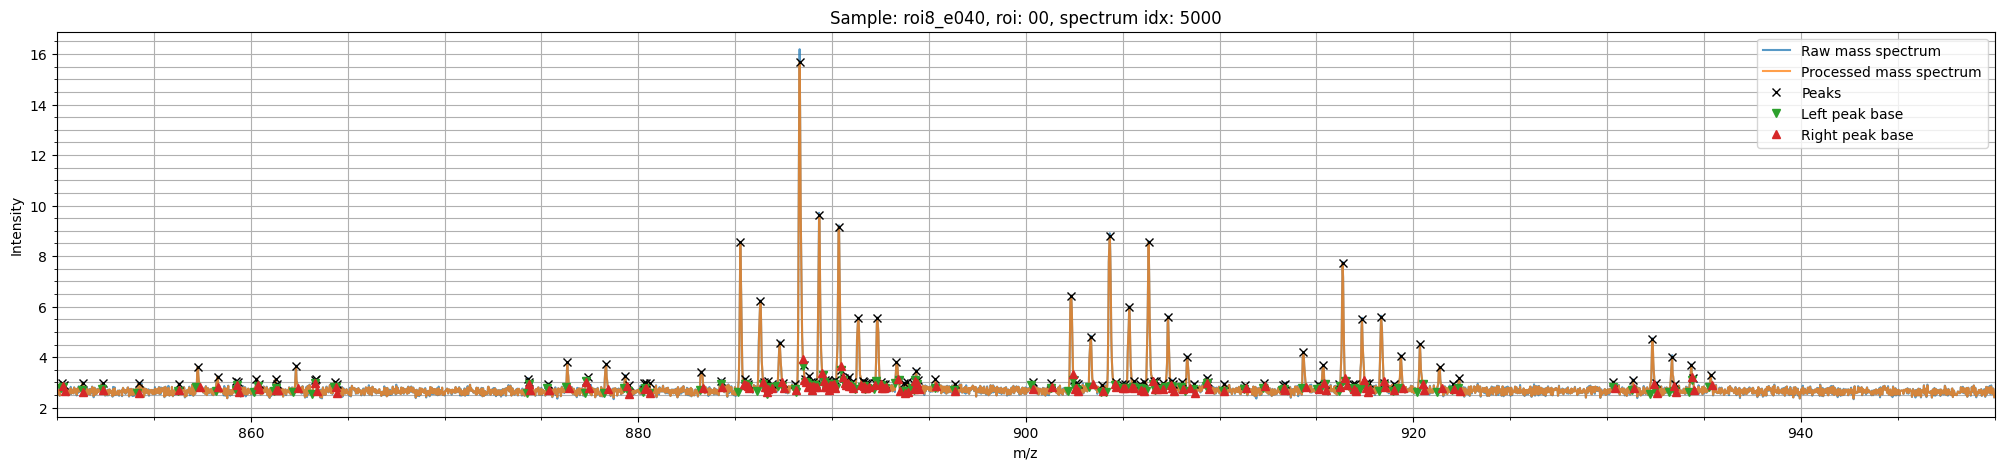

In [6]:
dataset["roi8_e040"].audit_processing(draw_mz_range=(850,950), draw_spectrum_idx=5000)

Если результат устраивает, то для запуска обработки данных у датасета есть два метода `process` и `peakpick`. 

Результатом работы метода `process` будут hdf5 файлы с записанными в них масс спектрами (но необходимо, чтобы были континуальными или настроить ресемплинг), которые лежат в папке `processed_pelmesha` в директории файла семпла. Матрицы в формате матрицы (N, M) - где N - количество спектров, а M - количество точек масс спектра. 

Метод `peakpick` записывает пиклисты в hdf5 файл в той же папке в формате матрицы (N, M), где M - свойства пиков (включая принадлежность к индексу масс спектра), а N - общее количество пиков всех масс спектров.

Processing SAMPLE roi1_e046...
Processing ROI 00


  0%|          | 0/141 [00:00<?, ?batch/s]

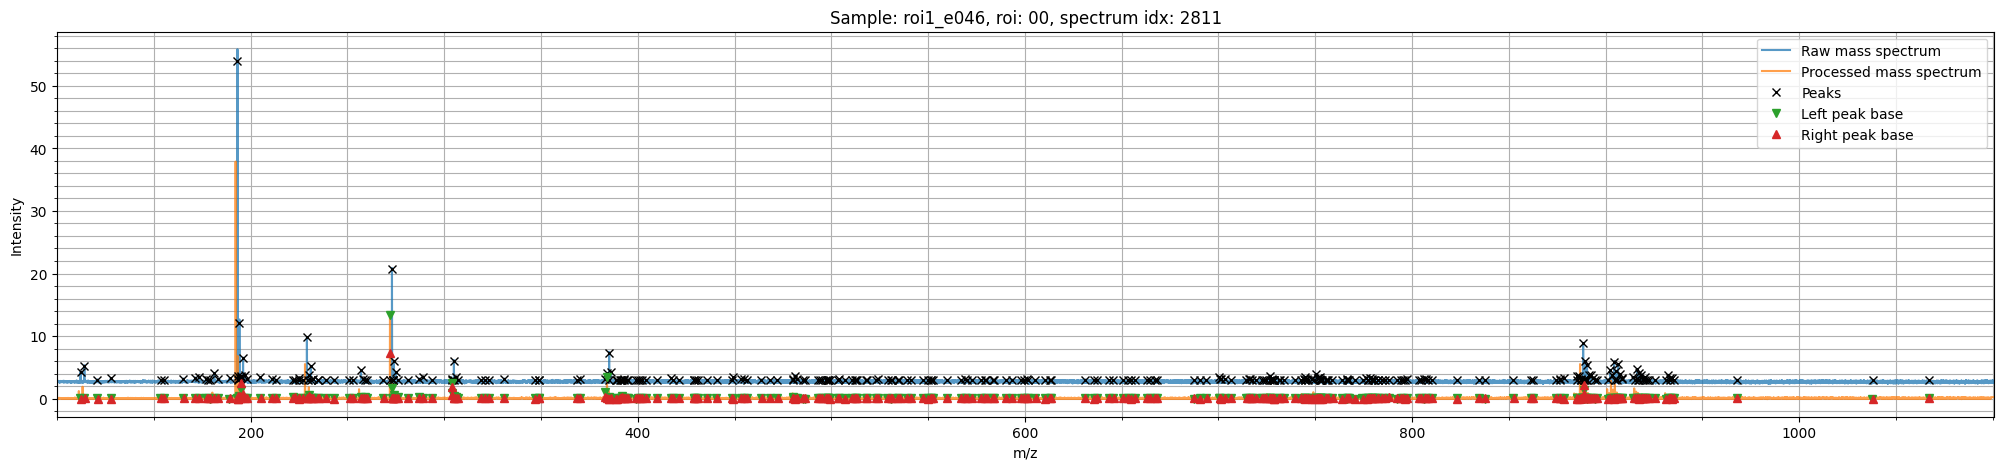

Processing SAMPLE roi3_e047...
Processing ROI 00


  0%|          | 0/48 [00:00<?, ?batch/s]

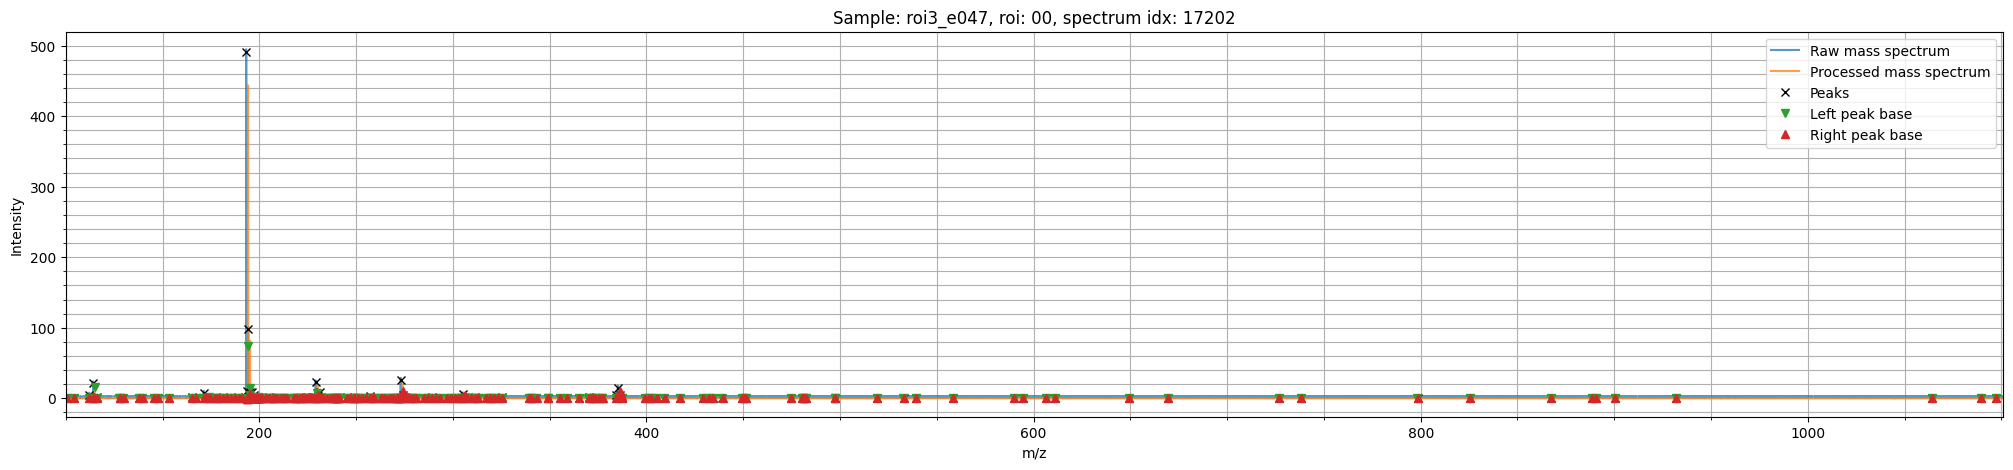

Processing SAMPLE roi8_e040...
Processing ROI 00


  0%|          | 0/113 [00:00<?, ?batch/s]

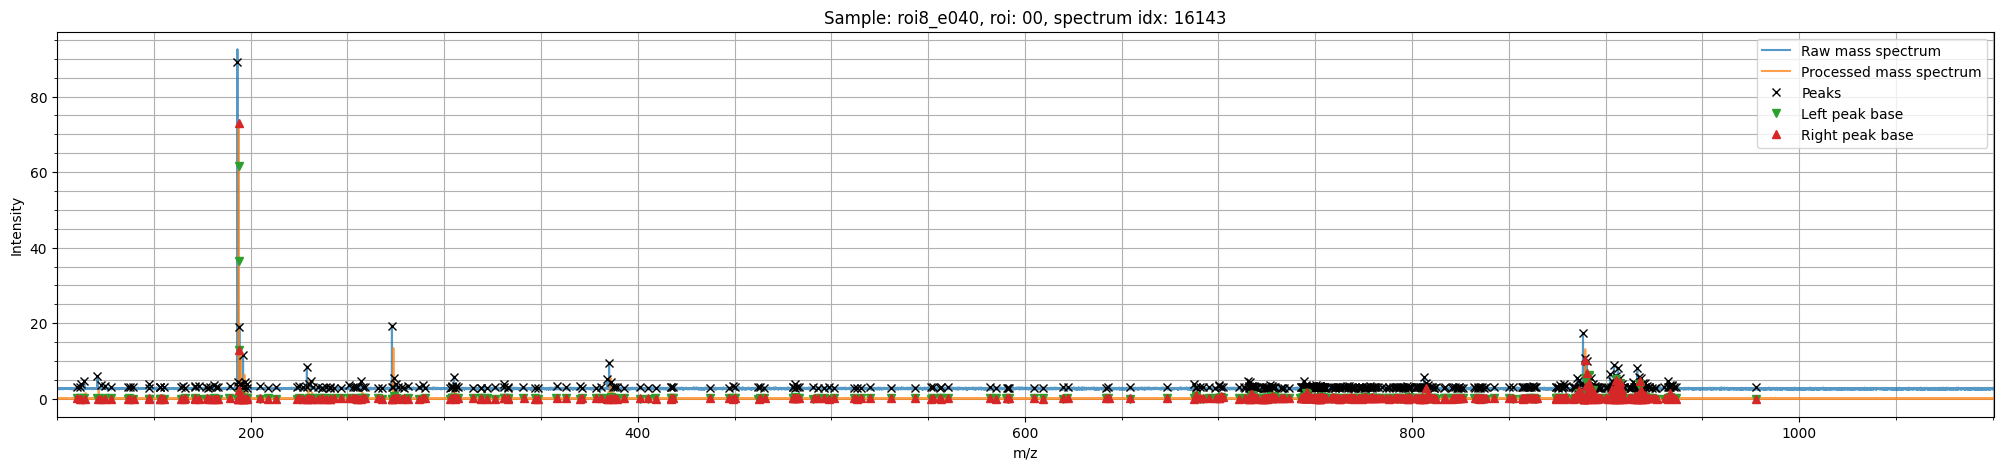

In [7]:
dataset.peakpick()

Deleted entire class 'Baseline' from methods.
Configs(
  functions:
    resample_mz_scale: resample_mz_step=None, resample_num_points=None
    peakpicker: fwhhfilter=None, oversegmentationfilter=None, heightfilter=None, rel_heightfilter=None, peaklocation=1, noise_func=np.std, noise_est_iterations=3, SNR_threshold=5, Calc_peak_area=True, headers=['spectra_ind', 'mz', 'Intensity', 'Area', 'SNR', 'PextL', 'PextR', 'FWHML', 'FWHMR', 'Noise', 'Mean noise']
)
DataSet is initialized. Current data samples:
DataSet (empty)


c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:92: UserWarning: Accession MS:1000563 found with incorrect name "Thermo RAW file". Updating name to "Thermo RAW format".
  warn(
c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:92: UserWarning: Accession MS:1000590 found with incorrect name "contact organization". Updating name to "contact affiliation".
  warn(
c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:84: UserWarning: Accession MS:1000128 ("profile spectrum") found with mismatched name "positive scan". This is a known bug with some imzML conversion software - using accession MS:1000130 ("positive scan") instead.
  warn(
c:\Users\Kuzya\AppData\Local\Programs\Python\Python313\Lib\site-packages\pyimzml\ontology\ontology.py:92: UserWarning: Accession IMS:1000042 found with incorrect name "max count of pixel x". Updating name t

Processing SAMPLE 1_test1...
Processing ROI 00


  0%|          | 0/49 [00:00<?, ?batch/s]

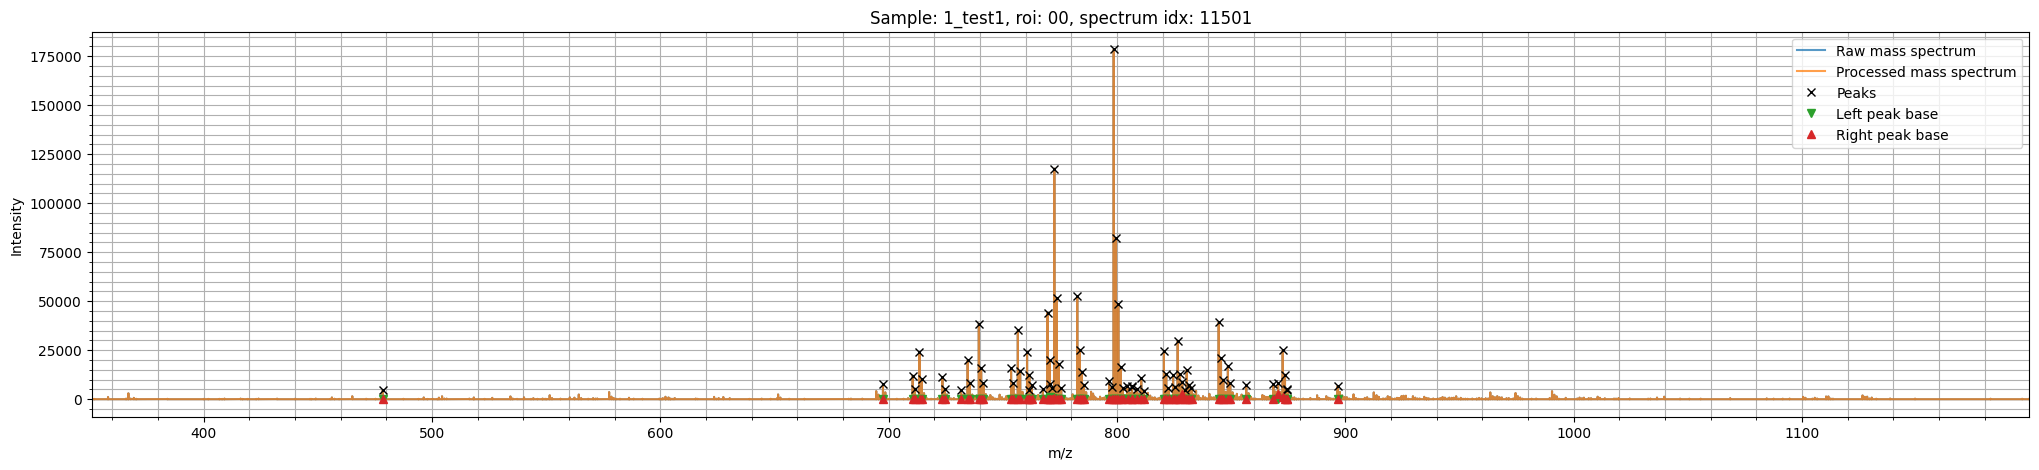

In [8]:
from pelmesha import DataSet, PipelineConfigurator
configs = PipelineConfigurator(SNR_threshold=5)
configs.delete('Baseline')
print(configs)
path = r'D:\Testing\Our_data\Orbitrap\1'
dataset = DataSet()
dataset.add_sources(path, configs)
dataset.peakpick()


In [9]:
from h5py import File
import pandas as pd
display(dataset)
with File(r'D:\Testing\Our_data\Orbitrap\1\processed_pelmesha\1_test1_peaklists.hdf5', 'r') as f:
    display(pd.DataFrame(f['00']['peaklists'], columns= f['00']['peaklists'].attrs['Column headers'])['spectra_ind'].unique())

Sample name,Mass spectra number,Continious,Peaklists,Processed mass spectra,Directory,Previous configs
1_test1,65756,No,Yes,No,D:\Testing\Our_data\Orbitrap\1,Open


array([0.0000e+00, 4.0000e+00, 5.0000e+00, ..., 6.3884e+04, 6.3885e+04,
       6.3886e+04], shape=(62544,))